# Ablation: Loss Function Configuration

Comparing different combinations of global and component loss functions:

| Model | Global Loss | Component Loss |
|-------|------------|----------------|
| **CS-CLIP (NegCLIP + Comps w/ Neg)** | NegCLIP | NegCLIP (baseline) |
| CS-CLIP (NegCLIP + Comps) | NegCLIP | CLIP |
| CS-CLIP (CLIP + Comps w/ Neg) | CLIP | NegCLIP |
| CS-CLIP (CLIP + Comps) | CLIP | CLIP |

This ablation tests:
- **Global Loss**: Whether to use NegCLIP (with hard negatives) or standard CLIP loss for the full caption
- **Component Loss**: Whether to use NegCLIP (with hard negatives) or standard CLIP loss for component captions

The baseline uses NegCLIP for both global and component losses.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
from pathlib import Path

# Import shared ablation utilities
from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_line,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

In [15]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

# Baseline: NegCLIP global + NegCLIP component (with hard negatives everywhere)
# This is the standard CS-CLIP configuration

ABLATION_MODELS = {
    "CLIP + NegCLIP": {
        "csv_path": "../evaluation/ablations/09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_baseline.csv",
        "is_baseline": False,
        "description": "CLIP global + NegCLIP component",
        "global_loss": "CLIP",
        "comp_loss": "CLIP",
    },
    "CLIP + CLIP": {
        "csv_path": "../evaluation/ablations/09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_clip.csv",
        "is_baseline": False,
        "description": "CLIP global + CLIP component",
        "global_loss": "CLIP",
        "comp_loss": "NegCLIP",
    },
    "NegCLIP + NegCLIP (Baseline)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "NegCLIP global + NegCLIP component (baseline)",
        "global_loss": "NegCLIP",
        "comp_loss": "NegCLIP",
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

# Ablation metadata
ABLATION_NAME = "LOSS FUNCTION ABLATION"
PARAM_KEY = "global_loss"  # For display purposes
PARAM_LABEL = 'Loss Configuration'

print("Ablation: Loss Function Configuration")
print("="*60)
print("\n  Global Loss  |  Component Loss  |  Model")
print("  " + "-"*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {cfg['global_loss']:^12} |  {cfg['comp_loss']:^14}  |  {name}{baseline_mark}")

Ablation: Loss Function Configuration

  Global Loss  |  Component Loss  |  Model
  --------------------------------------------------
      CLIP     |       CLIP       |  CLIP + NegCLIP
      CLIP     |     NegCLIP      |  CLIP + CLIP
    NegCLIP    |     NegCLIP      |  NegCLIP + NegCLIP (Baseline) [BASELINE]


In [16]:
# =============================================================================
# LOAD DATA - Single Metric (Primary)
# =============================================================================

scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading CLIP + NegCLIP...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 56 datasets (step=15000)
Loading CLIP + CLIP...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 56 datasets (step=5000)
Loading NegCLIP + NegCLIP (Baseline)...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)

Common datasets (56): ['ColorFoil', 'VG_Relation', 'VG_Attribution', 'MMVP/Spatial', 'SPEC/absolute_size', 'VALSE/actions', 'ControlledImages/B', 'SPEC/relative_size', 'SugarCrepe/replace_att', 'VALSE/relations', 'ColorSwap', 'SugarCrepe/replace_rel', 'MMVP/Structural Character', 'ControlledImages/VG-One', 'SugarCrepe/swap_att', 'SugarCrepe++/replace_object', 'VALSE/noun phrases', 'SPEC/existence', 'ControlledImages/COCO-Two', 'SugarCrepe++/swap_atribute', 'MMVP/State', 'ControlledImages/COCO-One', 'SugarCrepe/replace_obj', 'SugarCrepe++/swap_object', 'VALSE/coreference', 'SPEC/absolute_spatial

In [17]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: LOSS FUNCTION CONFIGURATION")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: LOSS FUNCTION CONFIGURATION
Metric: text_contrastive_accuracy


,ColorFoil,VG_Relation,VG_Attribution,MMVP/Spatial,SPEC/absolute_size,VALSE/actions,ControlledImages/B,SPEC/relative_size,SugarCrepe/replace_att,VALSE/relations,ColorSwap,SugarCrepe/replace_rel,MMVP/Structural Character,ControlledImages/VG-One,SugarCrepe/swap_att,SugarCrepe++/replace_object,VALSE/noun phrases,SPEC/existence,ControlledImages/COCO-Two,SugarCrepe++/swap_atribute,MMVP/State,ControlledImages/COCO-One,SugarCrepe/replace_obj,SugarCrepe++/swap_object,VALSE/coreference,SPEC/absolute_spatial,MMVP/Quantity,MMVP/Color,COLA/multi_objects,COCO-CF,SugarCrepe++/replace_relation,BLA/co,VALSE/existence,NegBench/msr_vtt_mcq_rephrased_llama,MMVP/Text,VisMin,ControlledImages/VG-Two,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,BLA/ap,NegBench/VOC2007_mcq_llama3.1_rephrased,SPEC/relative_spatial,MMVP/Presence,Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,ControlledImages/A,SugarCrepe/add_obj,VALSE/counting,MMVP/Orientation,SPEC/count,COCO_Order,Winoground,SugarCrepe/add_att,BLA/rc,VALSE/plurals,MMVP/Camera Perspective,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CLIP + NegCLIP,89.000000,81.000000,63.200000,26.700000,38.200000,74.400000,31.600000,32.700000,88.100000,68.000000,56.300000,78.900000,13.300000,45.900000,71.300000,92.200000,93.100000,69.100000,50.700000,55.900000,6.700000,42.500000,94.800000,47.300000,62.600000,12.700000,0.000000,6.700000,44.800000,78.300000,65.400000,48.300000,82.600000,31.500000,13.300000,78.800000,52.300000,67.300000,76.000000,51.400000,38.700000,29.900000,20.000000,58.000000,31.400000,30.600000,91.500000,66.000000,6.700000,34.200000,49.400000,32.500000,83.200000,48.500000,70.000000,20.000000,51.700000
CLIP + CLIP,87.900000,52.400000,60.800000,40.000000,38.100000,67.600000,33.600000,32.000000,85.300000,63.700000,57.700000,72.000000,6.700000,45.600000,70.900000,91.200000,91.500000,61.700000,48.900000,54.700000,26.700000,43.500000,94.100000,44.100000,53.300000,12.800000,0.000000,0.000000,46.700000,78.600000,56.700000,49.000000,76.400000,27.500000,0.000000,78.300000,51.600000,63.700000,74.700000,50.600000,25.900000,30.800000,13.300000,39.400000,26.300000,30.300000,90.000000,64.300000,6.700000,35.700000,31.200000,32.000000,79.200000,49.000000,68.700000,6.700000,48.600000
NegCLIP + NegCLIP (Baseline),90.500000,86.300000,69.400000,46.700000,38.800000,83.200000,34.600000,32.700000,86.200000,70.100000,59.000000,79.700000,6.700000,45.100000,74.500000,91.700000,93.700000,68.700000,50.900000,56.500000,13.300000,48.000000,94.900000,52.200000,56.200000,12.200000,6.700000,13.300000,41.000000,78.200000,62.400000,48.400000,83.400000,29.200000,13.300000,78.600000,53.100000,69.000000,74.200000,52.700000,37.800000,29.500000,0.000000,96.700000,31.400000,29.100000,90.800000,66.500000,13.300000,34.500000,95.300000,29.800000,80.800000,49.600000,70.500000,6.700000,53.700000


In [18]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: LOSS FUNCTION - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading CLIP + NegCLIP...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading CLIP + CLIP...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading NegCLIP + NegCLIP (Baseline)...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (18): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VisMin', 'Winoground']

ABLATION: LOSS FUNCTION - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
CLIP + NegCLIP,57.200000,40.800000,25.700000,41.200000
CLIP + CLIP,52.400000,41.500000,25.600000,39.800000
NegCLIP + NegCLIP (Baseline),62.500000,41.600000,25.400000,43.200000


In [7]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Loss function ablation. Compares different combinations of global and component loss functions. Global Loss = loss on full captions, Component Loss = loss on component captions. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_loss_function",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Loss function ablation. Compares different combinations of global and component loss functions. Global Loss = loss on full captions, Component Loss = loss on component captions. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_loss_function}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    CLIP + CLIP & 57.2 & 40.8 & \textbf{25.7} & 41.2 \\
    CLIP + NegCLIP & 52.4 & 41.5 & 25.6 & 39.8 \\
    NegCLIP + CLIP & 52.4 & 40.4 & 25.0 & 39.3 \\
    NegCLIP + NegCLIP (Baseline) & \textbf{\underline{62.5}} & \textbf{\underline{41.6}} & \underline{25.4} & \textbf{\underline{43.2}} \\
    \bottomrule
  \end{tabular}
\end{table}


Saved: ../paper_figures/ablation_loss_function_bars.pdf


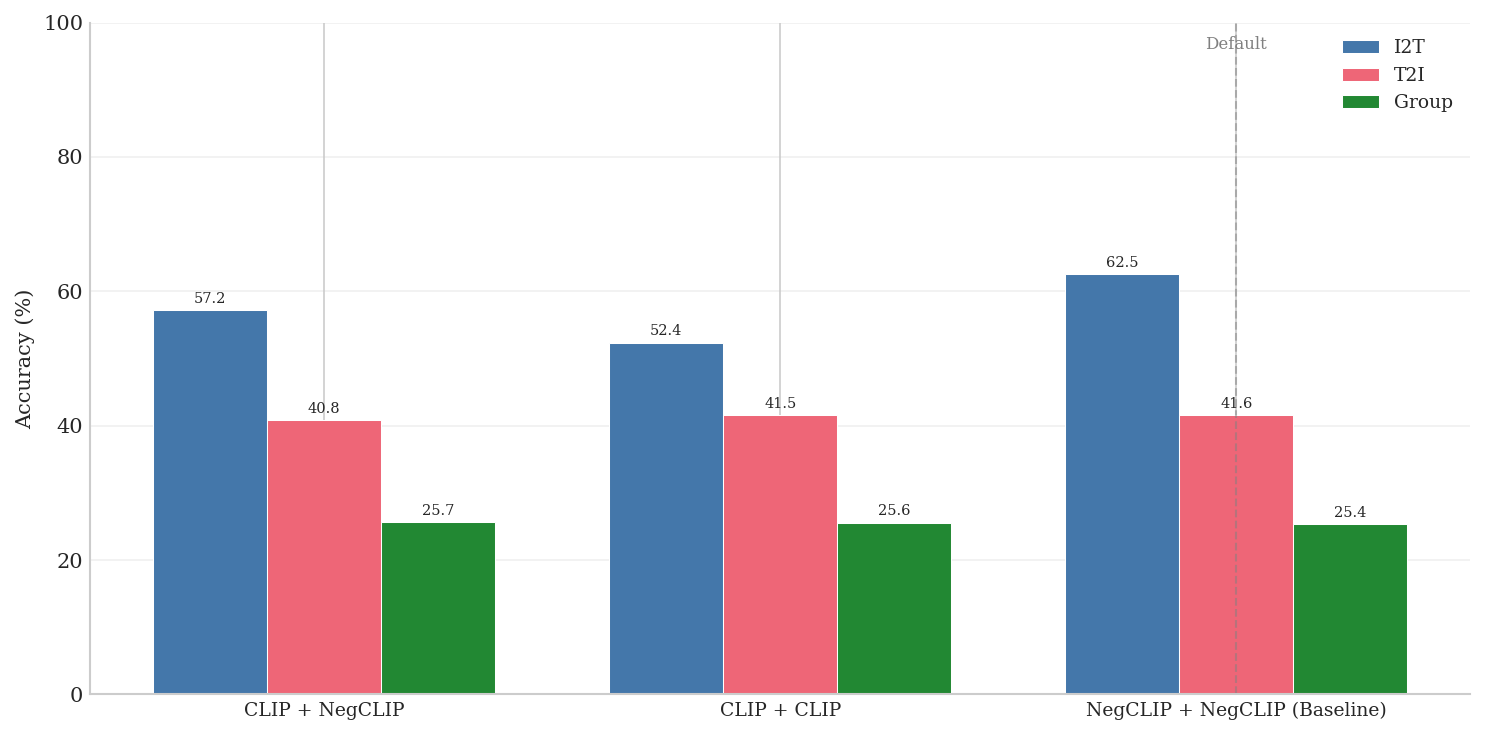

In [19]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Loss Function Ablation',
    save_path='../paper_figures/ablation_loss_function_bars.pdf'
)

KeyError: (1, 0)

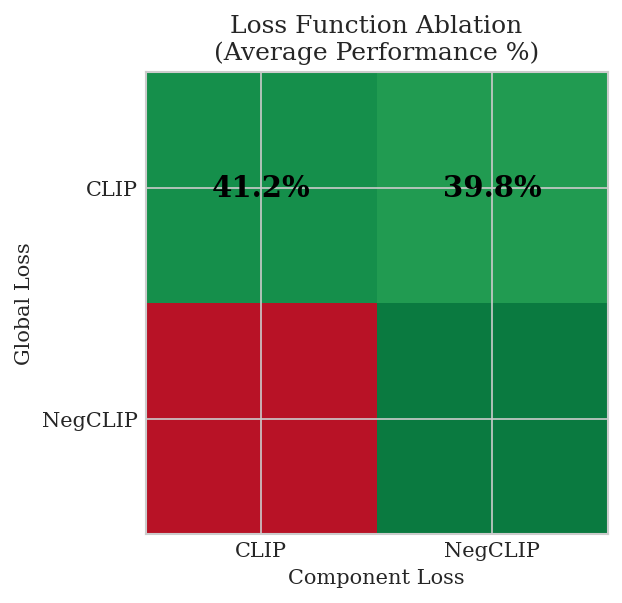

In [20]:
# =============================================================================
# CUSTOM VISUALIZATION: 2x2 HEATMAP
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Create 2x2 matrix for heatmap
# Rows: Global Loss (CLIP, NegCLIP)
# Cols: Component Loss (CLIP, NegCLIP)

loss_matrix = np.zeros((2, 2))
loss_labels = {}

for name, cfg in ABLATION_MODELS.items():
    row = 0 if cfg['global_loss'] == 'CLIP' else 1
    col = 0 if cfg['comp_loss'] == 'CLIP' else 1
    avg = summary_df.loc[name, 'Average'] * 100
    loss_matrix[row, col] = avg
    loss_labels[(row, col)] = f"{avg:.1f}%"

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(loss_matrix, cmap='RdYlGn', vmin=loss_matrix.min()-2, vmax=loss_matrix.max()+2)

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['CLIP', 'NegCLIP'])
ax.set_yticklabels(['CLIP', 'NegCLIP'])
ax.set_xlabel('Component Loss')
ax.set_ylabel('Global Loss')
ax.set_title('Loss Function Ablation\n(Average Performance %)')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, loss_labels[(i, j)],
                       ha="center", va="center", color="black", fontsize=14, fontweight='bold')

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Average Accuracy (%)', rotation=-90, va="bottom")

plt.tight_layout()
plt.savefig('../paper_figures/ablation_loss_function_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# =============================================================================
# SUMMARY
# =============================================================================

print_summary(summary_df, ABLATION_MODELS, ABLATION_NAME, PARAM_KEY)

# Additional analysis: Effect of each factor
print("\n" + "="*60)
print("FACTOR ANALYSIS")
print("="*60)

# Effect of NegCLIP on Global Loss (averaging over component loss)
global_clip = summary_df.loc[['CLIP + CLIP', 'CLIP + NegCLIP'], 'Average'].mean() * 100
global_negclip = summary_df.loc[['NegCLIP + CLIP', 'NegCLIP + NegCLIP (Baseline)'], 'Average'].mean() * 100
print(f"\nGlobal Loss Effect:")
print(f"  CLIP global avg:    {global_clip:.2f}%")
print(f"  NegCLIP global avg: {global_negclip:.2f}%")
print(f"  Δ (NegCLIP - CLIP): {global_negclip - global_clip:+.2f}%")

# Effect of NegCLIP on Component Loss (averaging over global loss)
comp_clip = summary_df.loc[['CLIP + CLIP', 'NegCLIP + CLIP'], 'Average'].mean() * 100
comp_negclip = summary_df.loc[['CLIP + NegCLIP', 'NegCLIP + NegCLIP (Baseline)'], 'Average'].mean() * 100
print(f"\nComponent Loss Effect:")
print(f"  CLIP component avg:    {comp_clip:.2f}%")
print(f"  NegCLIP component avg: {comp_negclip:.2f}%")
print(f"  Δ (NegCLIP - CLIP):    {comp_negclip - comp_clip:+.2f}%")

In [21]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)


PER-DATASET RESULTS (I2T)
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
[apply_mappings] Dropped 16 original rows replaced by aliased metrics


,ARO,BLA,COCO-CF,COLA,ColorFoil,ColorSwap,ControlledImages,MMVP,NegBench,SPEC,SugarCrepe,SugarCrepe++,VALSE,VisMin,Winoground,Average
Model,,,,,,,,,,,,,,,,
CLIP + NegCLIP,62.900000,49.400000,78.300000,44.800000,89.000000,56.300000,42.300000,12.600000,33.900000,36.100000,82.200000,67.400000,73.800000,78.800000,32.500000,56.000000
CLIP + CLIP,45.900000,49.500000,78.600000,46.700000,87.900000,57.700000,42.200000,11.100000,26.600000,35.200000,79.300000,64.300000,69.400000,78.300000,32.000000,53.600000
NegCLIP + NegCLIP (Baseline),86.900000,50.200000,78.200000,41.000000,90.500000,59.000000,43.500000,13.300000,32.800000,36.100000,82.200000,67.400000,74.800000,78.600000,29.800000,57.600000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-dataset I2T accuracy.}
  \label{tab:ablation_datasets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{ARO} & \rotatebox{60}{BLA} & \rotatebox{60}{COCO-CF} & \rotatebox{60}{COLA} & \rotatebox{60}{ColorFoil} & \rotatebox{60}{ColorSwap} & \rotatebox{60}{ControlledImages} & \rotatebox{60}{MMVP} & \rotatebox{60}{NegBench} & \rotatebox{60}{SPEC} & \rotatebox{60}{SugarCrepe} & \rotatebox{60}{SugarCrepe++} & \rotatebox{60}{VALSE} & \rotatebox{60}{VisMin} & \rotatebox{60}{Winoground} & \rotatebox{60}{Avg} \\
    \midrule
    CLIP + NegCLIP & 62.9 & 49.4 & 78.3 & 44.8 & 89.0 & 56.3 & 42.3 & 12.6 & \textbf{33.9} & \textbf{36.1} & 82.2 & 67.4 & 73.8 & \textbf{78.8} & \textbf{32.5} & 56.0 \\
    CLIP + CLIP & 45.9 & 49.5 & \textbf{78.6} & \textbf{46.7} & 87.9 & 57.7 & 42.2 & 11.1 & 26.6 & 35.2 & 79.3 & 64.3 & 69.4 & 78.3 & 32.0 & 53.6 \\
    NegCLIP + NegCLI

,ColorFoil,ARO/VG_Relation,ARO/VG_Attribution,MMVP/Spatial,SPEC/absolute_size,VALSE/actions,ControlledImages/B,SPEC/relative_size,SugarCrepe/replace_att,VALSE/relations,ColorSwap,SugarCrepe/replace_rel,MMVP/Structural Character,ControlledImages/VG-One,SugarCrepe/swap_att,SugarCrepe++/replace_object,VALSE/noun phrases,SPEC/existence,ControlledImages/COCO-Two,SugarCrepe++/swap_atribute,MMVP/State,ControlledImages/COCO-One,SugarCrepe/replace_obj,SugarCrepe++/swap_object,VALSE/coreference,SPEC/absolute_spatial,MMVP/Quantity,MMVP/Color,COLA/multi_objects,COCO-CF,SugarCrepe++/replace_relation,BLA/co,VALSE/existence,NegBench/msr_vtt_mcq_rephrased_llama,MMVP/Text,VisMin,ControlledImages/VG-Two,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,BLA/ap,NegBench/VOC2007_mcq_llama3.1_rephrased,SPEC/relative_spatial,MMVP/Presence,ARO/Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,ControlledImages/A,SugarCrepe/add_obj,VALSE/counting,MMVP/Orientation,SPEC/count,ARO/COCO_Order,Winoground,SugarCrepe/add_att,BLA/rc,VALSE/plurals,MMVP/Camera Perspective,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CLIP + NegCLIP,89.000000,81.000000,63.200000,26.700000,38.200000,74.400000,31.600000,32.700000,88.100000,68.000000,56.300000,78.900000,13.300000,45.900000,71.300000,92.200000,93.100000,69.100000,50.700000,55.900000,6.700000,42.500000,94.800000,47.300000,62.600000,12.700000,0.000000,6.700000,44.800000,78.300000,65.400000,48.300000,82.600000,31.500000,13.300000,78.800000,52.300000,67.300000,76.000000,51.400000,38.700000,29.900000,20.000000,58.000000,31.400000,30.600000,91.500000,66.000000,6.700000,34.200000,49.400000,32.500000,83.200000,48.500000,70.000000,20.000000,51.700000
CLIP + CLIP,87.900000,52.400000,60.800000,40.000000,38.100000,67.600000,33.600000,32.000000,85.300000,63.700000,57.700000,72.000000,6.700000,45.600000,70.900000,91.200000,91.500000,61.700000,48.900000,54.700000,26.700000,43.500000,94.100000,44.100000,53.300000,12.800000,0.000000,0.000000,46.700000,78.600000,56.700000,49.000000,76.400000,27.500000,0.000000,78.300000,51.600000,63.700000,74.700000,50.600000,25.900000,30.800000,13.300000,39.400000,26.300000,30.300000,90.000000,64.300000,6.700000,35.700000,31.200000,32.000000,79.200000,49.000000,68.700000,6.700000,48.600000
NegCLIP + NegCLIP (Baseline),90.500000,86.300000,69.400000,46.700000,38.800000,83.200000,34.600000,32.700000,86.200000,70.100000,59.000000,79.700000,6.700000,45.100000,74.500000,91.700000,93.700000,68.700000,50.900000,56.500000,13.300000,48.000000,94.900000,52.200000,56.200000,12.200000,6.700000,13.300000,41.000000,78.200000,62.400000,48.400000,83.400000,29.200000,13.300000,78.600000,53.100000,69.000000,74.200000,52.700000,37.800000,29.500000,0.000000,96.700000,31.400000,29.100000,90.800000,66.500000,13.300000,34.500000,95.300000,29.800000,80.800000,49.600000,70.500000,6.700000,53.700000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-subset I2T accuracy.}
  \label{tab:ablation_subsets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccccccccccccccccccccccccccccccccccccccccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{ColorFoil} & \rotatebox{60}{ARO/VG\_Relation} & \rotatebox{60}{ARO/VG\_Attribution} & \rotatebox{60}{MMVP/Spatial} & \rotatebox{60}{SPEC/absolute\_size} & \rotatebox{60}{VALSE/actions} & \rotatebox{60}{ControlledImages/B} & \rotatebox{60}{SPEC/relative\_size} & \rotatebox{60}{SugarCrepe/replace\_att} & \rotatebox{60}{VALSE/relations} & \rotatebox{60}{ColorSwap} & \rotatebox{60}{SugarCrepe/replace\_rel} & \rotatebox{60}{MMVP/Structural Character} & \rotatebox{60}{ControlledImages/VG-One} & \rotatebox{60}{SugarCrepe/swap\_att} & \rotatebox{60}{SugarCrepe++/replace\_object} & \rotatebox{60}{VALSE/noun phrases} & \rotatebox{60}{SPEC/existence} & \rotatebox{60}{ControlledImages/COCO-Two} & \rotatebox{60}{SugarCr